<div style="background:#0A2540;color:white;padding:18px 22px;border-radius:8px"><div style="color:#F4B942;font-weight:700;letter-spacing:1px">WEEK 7 · TUTORIAL 2 (LIVE SCRIPT)</div><div style="font-size:24px;font-weight:800;margin:4px 0">Optimization Techniques</div><div style="opacity:.9">Feature engineering, hyperparameter tuning &amp; cross-validation — squeezing more out of your models.</div><div style="margin-top:8px;font-size:13px;opacity:.75">Audience: Caribbean Clinical-AI trainees · Mercer General Hospital · dataset: Yale EMMLC (raw → cleaned)</div></div>

### What you'll do today
1. Load and clean the **raw** triage file, and rebuild your **Week 6 split**.
2. Learn what **feature engineering** is — and add a couple of clinical features.
3. Train a **Random Forest**, then **tune** it with cross-validation.
4. Meet **gradient boosting** and a **small neural network (MLP)**.
5. Save your best models for next tutorial's six-axis benchmark.

Goal for the week: not 'the best model', but *the most defensible* one. Today is about getting real, tuned candidates ready to benchmark honestly in Tutorial 3.

<div style="border-left:6px solid #1B9AAA;background:#1B9AAA14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>The ED Board liked your Week 6 baseline — now they ask: <i>does a fancier model actually help, and is it worth the extra compute?</i> Martina Griffith (Clinical IT) will want numbers. Everything today feeds that cost-benefit decision.</div>

In [14]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the tools we need.
#   pandas / numpy  — tables and maths
#   matplotlib      — charts
#   scikit-learn    — the machine-learning toolkit (models + tuning)
#   joblib          — save trained models to a file
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

Libraries loaded. ✅


## 1 · Load and clean the raw data

In [15]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the RAW triage export.
# In Colab it reads the file from your mounted Drive; if you're running
# locally it falls back to a copy in the same folder.
# The file name is the real one you were given: yaleemmlc_admissionprediction_triage.csv
# ------------------------------------------------------------------
import os

# mount Drive
from google.colab import drive
drive.mount('/content/drive')

RAW = "yaleemmlc_admissionprediction_triage.csv"
DRIVE = "/content/drive/MyDrive/Carisurg/yaleemmlc_admissionprediction_triage.csv"
path = DRIVE if os.path.exists(DRIVE) else RAW
df_raw = pd.read_csv(path)
print("Loaded", df_raw.shape[0], "rows and", df_raw.shape[1], "columns from:", path)
df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55121 rows and 226 columns from: /content/drive/MyDrive/Carisurg/yaleemmlc_admissionprediction_triage.csv


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>We load the <b>raw</b> file (<code>yaleemmlc_admissionprediction_triage.csv</code>) and clean it here so the notebook is self-contained. <code>pd.to_numeric(..., errors="coerce")</code> turns junk text into NaN; we drop rows with an unusable ESI label; then we fill remaining gaps with each column's median.</div>

In [16]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: turns the raw, messy export into a modelling-ready
# table. This is the SAME cleaning you did in Week 5, in compact form, so
# this notebook stands on its own.
# ------------------------------------------------------------------
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
df = df_raw.copy()

# drop any stray index column (e.g. "Unnamed: 0") that pandas adds — it is not real data
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# 1) force the vitals to be NUMBERS; unparseable text (e.g. "120bpm") becomes NaN
for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) the ESI label must be 1-5. Drop rows where it is missing or out of range —
#    a row with no valid triage label cannot teach a triage model.
df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

# 3) blank out physically impossible vitals so they don't poison the model
df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

# 4) encode gender to 0/1 (handles odd casings like "m" / "MALE")
df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

# 5) fill remaining missing NUMBERS with the column median (simple and defensible)
for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


## 2 · Choose the features (X) and the target (y)

📚 **scikit-learn docs:** [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>We group the columns by <i>meaning</i> so our feature choice is transparent. <b>Vitals</b> and <b>chief-complaint flags</b> are fair game. We deliberately exclude three groups: <b>leakage</b> (<code>disposition</code>, <code>previousdispo</code> — known only AFTER triage), <b>admin / arrival</b> details, and — for now — <b>demographics</b> (age, gender, race…), some of which are fairness-sensitive. Section 7 shows how to encode and add demographics back if you choose to.</div>

In [17]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: chooses which columns the model may use (X) and
# what it must predict (y), grouped by meaning so the choice is transparent.
# ------------------------------------------------------------------
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

X = df[FEATURES]
y = df[TARGET]
print("Model will use", len(FEATURES), "features. First few:", FEATURES[:6])

Model will use 208 features. First few: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device']


In [18]:
# Reproduce the EXACT Week 6 split (same random_state = 42 -> identical test patients).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 44096 | test: 11025


<div style="border-left:6px solid #33608C;background:#33608C14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#33608C">💬 DISCUSS</b><br><b>Is <code>cc_other</code> worth keeping?</b> Most chief-complaint flags are specific (chest pain, fever, shortness of breath…). But <code>cc_other</code> is a <i>catch-all</i> for everything that didn’t fit a named category. Talk it through:<br>• Does a flag that just means ‘something else’ carry any signal a model can actually learn from?<br>• Could it be quietly absorbing rare-but-serious presentations that really deserve their own flag?<br>• Would you <b>keep</b> it, <b>drop</b> it, or <b>investigate what’s inside it</b> first?<br>The cell below helps you look before you decide.</div>

In [19]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: sizes up the cc_other catch-all so you can judge it.
# (Skips safely if your extract doesn't include a cc_other column.)
# ------------------------------------------------------------------
if "cc_other" in df.columns:
    cc_cols = [c for c in df.columns if c.startswith("cc_")]
    total = len(df)
    has_other = int(df["cc_other"].sum())
    only_other = int(((df["cc_other"] == 1) & (df[cc_cols].sum(axis=1) == 1)).sum())
    print(f"Patients flagged cc_other: {has_other} of {total} ({has_other/total:.1%})")
    print(f"...and of those, patients whose ONLY complaint is 'other': {only_other}")
    print("\nMean ESI by cc_other flag (does 'other' lean urgent or not?):")
    print(df.groupby("cc_other")["esi"].mean().round(2))
else:
    print("No cc_other column in this sample — skipping. (On the full extract it will run.)")

Patients flagged cc_other: 4491 of 55121 (8.1%)
...and of those, patients whose ONLY complaint is 'other': 3352

Mean ESI by cc_other flag (does 'other' lean urgent or not?):
cc_other
0.0    2.87
1.0    3.01
2.0    3.26
3.0    3.00
Name: esi, dtype: float64


## 3 · Recap: the Week 6 baseline to beat

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>We quickly retrain the Week 6 <b>logistic regression</b> baseline (scaled) and record its <b>macro-F1</b> — the average F1 across all five ESI levels, which treats the rare, critical ESI 1 as equal to the common ESI 3. Every advanced model today has to beat this number to justify its extra cost.</div>

In [20]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: rebuilds the Week 6 baseline so we have a bar to clear.
# ------------------------------------------------------------------
baseline = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=42))
baseline.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, baseline.predict(X_test), average="macro")
print("Baseline (logistic regression) macro-F1:", round(baseline_f1, 3))

Baseline (logistic regression) macro-F1: 0.492


## 4 · Why optimize at all?

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A model 'out of the box' uses default settings that were chosen to be reasonable on average — not for <i>your</i> data. <b>Optimization</b> means two things: (1) <b>feature engineering</b> — giving the model better clues, and (2) <b>hyperparameter tuning</b> — adjusting the model's own dials. Both can lift performance without collecting a single new patient.</div>

## 5 · Feature engineering

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A <b>feature</b> is a clue the model uses. <b>Feature engineering</b> builds new clues from existing columns using clinical knowledge. Two handy patterns: <b>ratios / combinations</b> (e.g. <b>shock index</b> = HR ÷ SBP, a red flag neither vital shows alone) and <b>red-flag flags</b> (a 0/1 for an abnormal reading). We build them <i>row by row</i>, so they are safe to apply to train and test separately (no leakage).<br><br><b>Don’t lean only on blood pressure</b> — it is often missing or mis-measured at triage. Features built from <b>respiratory rate, oxygen saturation, temperature and glucose</b> capture an independent axis of how sick a patient is.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Finish <code>add_clinical_features</code> by adding one or two red-flag features of your own that <b>do not use blood pressure</b> — e.g. hypoxia (O₂ &lt; 92) or fever (temp ≥ 100.4).</div>

In [25]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: builds new clinical features from existing vitals,
# then applies them to BOTH the train and test sets in the same way.
# ------------------------------------------------------------------
def add_clinical_features(data):
    out = data.copy()

    # --- ratios & combinations (given as examples) ---
    out["shock_index"] = (
        out["triage_vital_hr"] / out["triage_vital_sbp"]
    )

    out["pulse_pressure"] = (
        out["triage_vital_sbp"] - out["triage_vital_dbp"]
    )

    # Estimate mean arterial pressure using diastolic pressure
    # and one-third of the pulse pressure.
    # Comment this out to compare performance without MAP.
    out["map_estimate"] = (
        out["triage_vital_dbp"] +
        out["pulse_pressure"] / 3
    )

    out["spo2_rr_ratio"] = (
        out["triage_vital_o2"] / out["triage_vital_rr"]
    )

    # Red-flag features that do not use blood pressure
    out["is_tachypneic"] = (
        out["triage_vital_rr"] > 20
    ).astype(int)

    out["is_hypoxic"] = (
        out["triage_vital_o2"] < 92
    ).astype(int)

    out["is_febrile"] = (
        out["triage_vital_temp"] >= 100.4
    ).astype(int)

    # Number of red flags present for each patient
    flag_columns = [
        "is_tachypneic",
        "is_hypoxic",
        "is_febrile"
    ]

    out["red_flag_count"] = out[flag_columns].sum(axis=1)

    return out


X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)

print("Features after engineering:", X_train_fe.shape[1])
X_train_fe.head()

Features after engineering: 216


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,cc_wristinjury,cc_wristpain,shock_index,pulse_pressure,map_estimate,spo2_rr_ratio,is_tachypneic,is_hypoxic,is_febrile,red_flag_count
35369,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,0.0,0.0,0.866667,49.0,87.333333,4.454545,1,0,0,1
52043,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0.0,0.0,0.678261,39.0,89.000000,5.333333,0,0,0,0
13610,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0.0,0.0,0.806723,41.0,91.666667,5.222222,0,0,0,0
54796,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0.0,0.0,0.695312,35.0,104.666667,6.125000,0,0,0,0
11096,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0.0,0.0,0.787611,35.0,89.666667,5.444444,0,0,0,0


In [26]:
# Apply the updated feature-engineering function
# consistently to both datasets.
X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)

print("Number of engineered features:", X_train_fe.shape[1])
X_train_fe.head()

Number of engineered features: 216


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,cc_wristinjury,cc_wristpain,shock_index,pulse_pressure,map_estimate,spo2_rr_ratio,is_tachypneic,is_hypoxic,is_febrile,red_flag_count
35369,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,0.0,0.0,0.866667,49.0,87.333333,4.454545,1,0,0,1
52043,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0.0,0.0,0.678261,39.0,89.000000,5.333333,0,0,0,0
13610,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0.0,0.0,0.806723,41.0,91.666667,5.222222,0,0,0,0
54796,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0.0,0.0,0.695312,35.0,104.666667,6.125000,0,0,0,0
11096,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0.0,0.0,0.787611,35.0,89.666667,5.444444,0,0,0,0


**More features you could try** (★ = no blood pressure needed):
- ★ `is_bradycardic` = HR &lt; 60 — a dangerously slow heart rate
- ★ `is_hyperglycaemic` = glucose &gt; 180 — poorly controlled or physiologically stressed
- ★ `is_hypothermic` = temp &lt; 96.8 — as concerning as a fever
- ★ `resp_distress` = 1 if hypoxic **or** tachypneic — a combined respiratory red flag
- ★ `spo2_rr_ratio` = O₂ ÷ RR — a simple respiratory-distress index (used above)
- `map_estimate` = DBP + pulse\_pressure ÷ 3 — mean arterial pressure (this one *does* use BP)

Rule of thumb: build features across *different* body systems — heart, lungs, temperature, metabolism — so the model doesn’t over-rely on any single vital, or on blood pressure alone.

## 6 · Model 1 — Random Forest

📚 **scikit-learn docs:** [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)  ·  [`Ensembles (user guide)`](https://scikit-learn.org/stable/modules/ensemble.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A <b>random forest</b> trains many decision trees, each on a random slice of the data and features, then lets them <b>vote</b>. One tree can overfit; a whole forest averages out the noise. It needs <b>no scaling</b> (trees compare thresholds), and it hands you <code>feature_importances_</code> — how much each clue mattered. <code>class_weight="balanced"</code> tells it to care more about the rare ESI 1.</div>

Picture the structure — lots of independent trees, one shared vote:

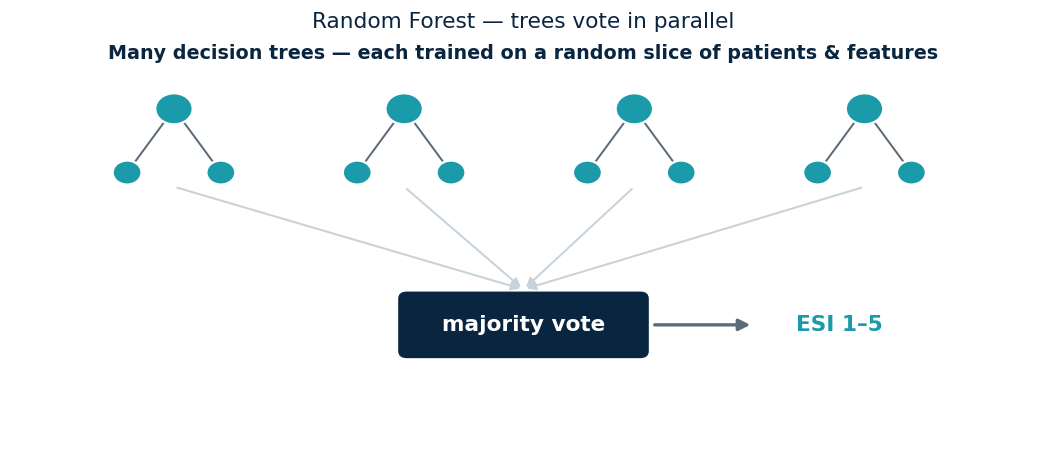

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Train a <code>RandomForestClassifier</code> on the engineered training data, then print its macro-F1 on the test set and its top feature importances.</div>

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Create the random forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train it on the feature-engineered training data
rf.fit(X_train_fe, y_train)

# Make predictions
rf_preds = rf.predict(X_test_fe)

# Calculate macro F1
rf_f1 = f1_score(
    y_test,
    rf_preds,
    average="macro"
)

print("Random Forest Macro F1:", round(rf_f1, 4))

# Rank the features by importance
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

print("\nTop 15 feature importances:")
print(rf_importance.head(15))

Random Forest Macro F1: 0.3831

Top 15 feature importances:
map_estimate              0.070792
shock_index               0.068410
triage_vital_sbp          0.067386
triage_glucose            0.063726
triage_vital_dbp          0.063434
pulse_pressure            0.061693
triage_vital_hr           0.061027
triage_vital_temp         0.056879
spo2_rr_ratio             0.048203
cc_strokealert            0.035996
triage_vital_o2           0.035779
triage_vital_rr           0.028536
cc_abdominalpain          0.026343
triage_vital_o2_device    0.023264
cc_chestpain              0.012435
dtype: float64


## 7 · Encoding categorical features

📚 **scikit-learn docs:** [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Machine-learning models only understand <b>numbers</b>. Columns like <code>gender</code>, <code>ethnicity</code> and <code>race</code> are <b>categorical</b> (text labels), so we must convert them first. Two common ways: a <b>binary</b> column (gender) becomes a single 0/1; a <b>multi-category</b> column becomes <b>one-hot</b> — one new 0/1 column per category (<code>pd.get_dummies</code>, or scikit-learn’s <code>OneHotEncoder</code>). We left demographics out of the base model earlier; here is how you would bring them in.</div>

In [28]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: turns the text demographic columns into numbers.
#   gender          -> already 0/1 from cleaning (binary needs one column)
#   age             -> already numeric
#   ethnicity, race -> ONE-HOT: one new 0/1 column per category
# ------------------------------------------------------------------
demo_1hot = pd.get_dummies(df[["ethnicity", "race"]], prefix=["eth", "race"], dtype=int)
print("New one-hot columns:", list(demo_1hot.columns))

def add_demographics(X_fe):
    """Bolt the encoded demographics onto an existing feature frame (aligned by row)."""
    rows = X_fe.index
    extra = demo_1hot.loc[rows].copy()
    extra["age"] = df.loc[rows, "age"]         # numeric already
    extra["gender"] = df.loc[rows, "gender"]   # 0/1 already
    return pd.concat([X_fe, extra], axis=1)

X_train_plus = add_demographics(X_train_fe)
X_test_plus = add_demographics(X_test_fe)
print("Features WITHOUT demographics:", X_train_fe.shape[1])
print("Features WITH    demographics:", X_train_plus.shape[1])
X_train_plus.filter(like="race_").head()

New one-hot columns: ['eth_Hispanic or Latino', 'eth_Non-Hispanic', 'eth_Patient Refused', 'eth_Unknown', 'race_American Indian or Alaska Native', 'race_Asian', 'race_Black or African American', 'race_Native Hawaiian or Other Pacific Islander', 'race_Other', 'race_Patient Refused', 'race_Unknown', 'race_White or Caucasian']
Features WITHOUT demographics: 216
Features WITH    demographics: 230


,race_American Indian or Alaska Native,race_Asian,race_Black or African American,race_Native Hawaiian or Other Pacific Islander,race_Other,race_Patient Refused,race_Unknown,race_White or Caucasian
35369,0,0,0,0,1,0,0,0
52043,0,0,0,0,0,0,0,1
13610,0,0,0,0,0,0,0,1
54796,0,0,1,0,0,0,0,0
11096,0,0,0,0,0,0,0,1


<div style="border-left:6px solid #C0392B;background:#C0392B14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#C0392B">⚠️ DATA / SAFETY NOTE</b><br>Using <b>race</b> and <b>ethnicity</b> as model inputs is ethically sensitive (recall the Week 4 ethics work). A model that leans on them can entrench bias, and a higher accuracy score is <b>not</b> enough to justify it. Encode them to <i>understand</i> their effect — but keep them out of a deployed model unless you can defend the choice and governance signs off.</div>

<div style="border-left:6px solid #33608C;background:#33608C14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#33608C">💬 DISCUSS</b><br><b>Which demographics actually earn a place in the model?</b> Sort the demographic columns into three buckets and defend each one:<br>• <b>Clinically justified &amp; ethically fine</b> — e.g. <code>age</code>, which is tightly tied to physiology and risk. What is the clinical mechanism?<br>• <b>Fairness-sensitive</b> — <code>race</code>, <code>ethnicity</code>. They might raise accuracy, but should they? What bias could a model learn from them?<br>• <b>Probably noise, or a proxy</b> — <code>religion</code>, <code>maritalstatus</code>, <code>insurance_status</code>. If <code>insurance_status</code> helps, is the model learning medicine — or learning who has access to care? For each column you would keep, name the mechanism; for each you would drop, name what it might be a proxy for.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Train a <code>RandomForestClassifier</code> on <code>X_train_plus</code> (with the encoded demographics) and compare its macro-F1 to the demographics-free forest from Section 6. Did the extra features actually help?</div>

In [29]:
# Create a second random forest using the expanded feature set
rf_demo = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train it with the encoded demographic features included
rf_demo.fit(X_train_plus, y_train)

# Make predictions
rf_demo_preds = rf_demo.predict(X_test_plus)

# Calculate macro F1
rf_demo_f1 = f1_score(
    y_test,
    rf_demo_preds,
    average="macro"
)

# Compare both random forests
print("Random Forest without demographics:", round(rf_f1, 3))
print("Random Forest with demographics:   ", round(rf_demo_f1, 3))

Random Forest without demographics: 0.383
Random Forest with demographics:    0.38


Including the encoded demographic features did not improve performance. Macro F1 decreased slightly from 0.383 to 0.380, suggesting that the demographic variables provided little additional predictive value for this model.

## 8 · Hyperparameter tuning with cross-validation

📚 **scikit-learn docs:** [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  ·  [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  ·  [`Cross-validation (user guide)`](https://scikit-learn.org/stable/modules/cross_validation.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br><b>Hyperparameters</b> are the model's own dials — for a forest: how many trees, how deep, how many samples per leaf. We don't guess them by hand. <b>Cross-validation (CV)</b> splits the training data into folds and rotates which fold is held out, so a setting has to do well on several mini-tests, not get lucky once. <b>GridSearchCV</b> tries every combination (thorough but slow); <b>RandomizedSearchCV</b> samples a fixed number of random combinations (much faster, nearly as good) — our choice here.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Run a <code>RandomizedSearchCV</code> over a few random-forest settings, scoring by <code>f1_macro</code> with <code>cv=3</code>. Then read off <code>best_params_</code> and score the tuned model.</div>

In [30]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: searches random-forest settings with 3-fold CV and
# keeps the combination that scores best on macro-F1.
# ------------------------------------------------------------------
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 6, 10, 16],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
}
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Base random forest to tune
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Search across different parameter combinations
search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run the search using only the training data
search.fit(X_train_fe, y_train)

# Best cross-validation results
print("Best parameters:")
print(search.best_params_)

print("\nBest cross-validation macro F1:")
print(round(search.best_score_, 3))

# Evaluate the best model on the untouched test set
best_rf = search.best_estimator_
best_rf_preds = best_rf.predict(X_test_fe)

best_rf_test_f1 = f1_score(
    y_test,
    best_rf_preds,
    average="macro"
)

print("\nBest random forest test macro F1:")
print(round(best_rf_test_f1, 3))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


KeyboardInterrupt: 

## 9 · Model 2 — Gradient Boosting

📚 **scikit-learn docs:** [`HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Where a forest builds trees <i>in parallel</i> and votes, <b>gradient boosting</b> builds trees <b>one after another</b>, each new tree fixing the mistakes of the last. It's often the strongest model on tabular clinical data. We use scikit-learn's fast <code>HistGradientBoostingClassifier</code>; <b>XGBoost</b> and <b>LightGBM</b> are popular external libraries that do the same idea (see the challenge references).</div>

The structure is a chain, not a crowd — each tree learns from the previous tree's mistakes:

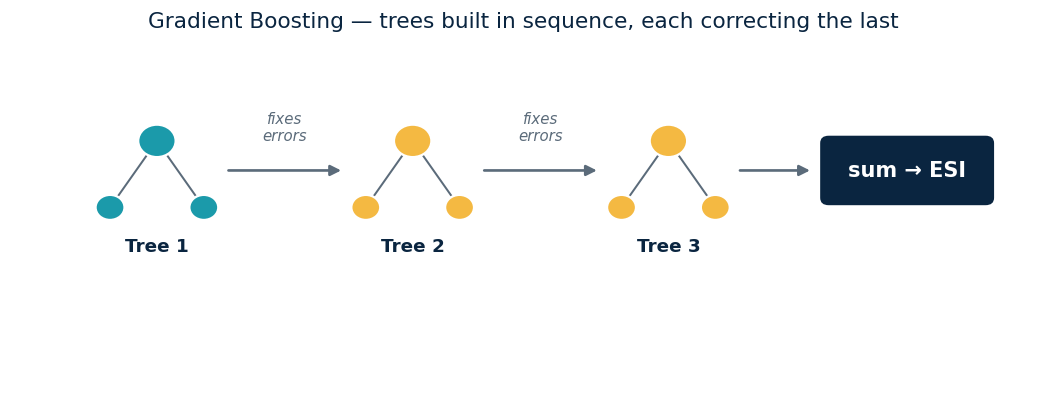

In [31]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: trains a gradient-boosting model. No scaling needed.
# ------------------------------------------------------------------
hgb = HistGradientBoostingClassifier(
    max_depth=6, learning_rate=0.1, max_iter=300,
    class_weight="balanced", random_state=42)
hgb.fit(X_train_fe, y_train)
hgb_f1 = f1_score(y_test, hgb.predict(X_test_fe), average="macro")
print("Gradient Boosting macro-F1:", round(hgb_f1, 3))

Gradient Boosting macro-F1: 0.432


## 10 · Model 3 — a small neural network (MLP)

📚 **scikit-learn docs:** [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)  ·  [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>An <b>MLP</b> (multi-layer perceptron) is a small neural network. On <i>tabular</i> data it rarely beats good tree models and is harder to explain, but it's worth knowing. It <b>needs scaling</b> (like logistic regression), so we wrap it in a pipeline with <code>StandardScaler</code>. Key dials: <code>hidden_layer_sizes</code> (network shape) and <code>alpha</code> (regularisation, to curb overfitting).</div>

Every input connects to every neuron in the next layer — that flexibility is its strength and its cost:

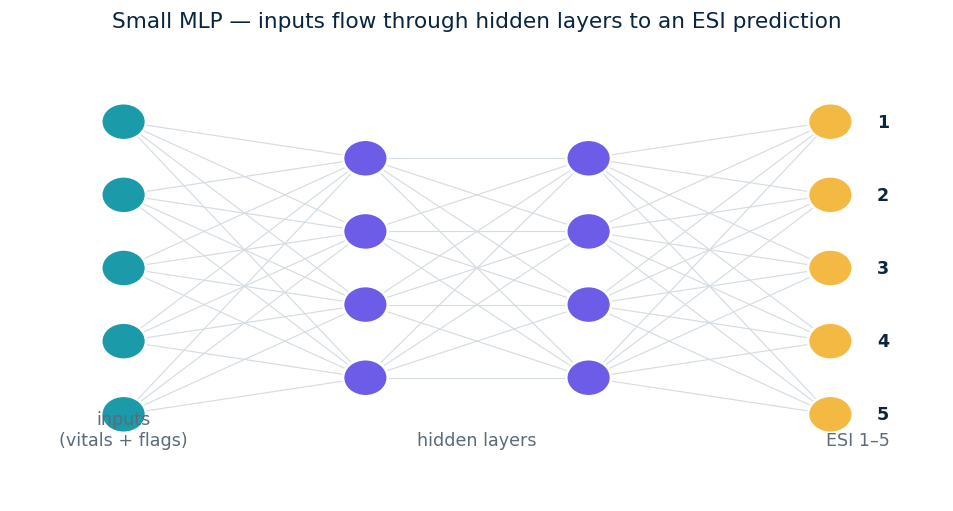

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: trains a small neural network on SCALED features.
# ------------------------------------------------------------------
mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=500, random_state=42))
mlp.fit(X_train_fe, y_train)
mlp_f1 = f1_score(y_test, mlp.predict(X_test_fe), average="macro")
print("Small MLP macro-F1:", round(mlp_f1, 3))

## 11 · The dials (hyperparameters) in plain English

📚 **scikit-learn docs:** [`Tuning hyper-parameters (user guide)`](https://scikit-learn.org/stable/modules/grid_search.html)

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A <b>hyperparameter</b> is a setting <i>you</i> choose before training — a dial on the model. (It is different from what the model <i>learns</i> from the data.) Below is what each dial we used actually means, in plain words. Every model has many more dials than we touched: the <b>complete list, with defaults and valid values, is in the ‘Parameters’ section of each model’s scikit-learn page</b>, linked below.</div>

### Random Forest &nbsp;—&nbsp; [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) *(full parameter list)*
- `n_estimators` — **how many trees** are in the forest. More trees = steadier predictions, but slower. (try 100–400)
- `max_depth` — **how many yes/no questions deep** each tree may go. Deeper fits more detail but risks memorising noise. (`None` = grow until pure)
- `min_samples_leaf` — the **fewest patients allowed in a final leaf**. Bigger = smoother, less overfitting.
- `max_features` — **how many features each split may consider**. Fewer = more variety between trees.
- `class_weight` — `"balanced"` tells it to **pay extra attention to rare classes** (like ESI 1).

### Gradient Boosting &nbsp;—&nbsp; [`HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) *(full parameter list)*
- `learning_rate` — **how big a correction each new tree makes**. Smaller = more careful, usually needs more rounds.
- `max_iter` — **how many boosting rounds** (trees built one after another).
- `max_depth` — **depth of each individual tree**. Boosting usually uses shallow trees.
- `class_weight` — as above, `"balanced"` up-weights the rare, critical classes.

### Small MLP (neural network) &nbsp;—&nbsp; [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) *(full parameter list)*
- `hidden_layer_sizes` — the **shape of the network**, e.g. `(64, 32)` = two hidden layers of 64 then 32 neurons. Bigger = more capacity, more overfit risk, more compute.
- `alpha` — **regularisation strength**: higher = a simpler model that overfits less.
- `max_iter` — **how many training passes** before it stops.

## 12 · Quick scoreboard (full benchmark is Tutorial 3)

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: lines up macro-F1 for every model so far. The FULL
# six-axis benchmark (with timing + interpretability) comes in Tutorial 3.
# ------------------------------------------------------------------
scores = {
    "Baseline (LogReg)": baseline_f1,
    "Random Forest": rf_f1,
    "Random Forest (tuned)": best_rf_test_f1,
    "Gradient Boosting": hgb_f1,
    "Small MLP": mlp_f1,
}

pd.Series(scores).sort_values(
    ascending=False
).round(3).to_frame("Macro F1")

## 13 · Save your tuned models

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br><code>joblib.dump(model, "file.joblib")</code> freezes a trained model to disk; <code>joblib.load("file.joblib")</code> brings it back with no retraining. Tutorial 3 will reload these to run the timing and interpretability benchmark, so save the tuned versions here.</div>

In [ ]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: saves the models Tutorial 3 will benchmark.
# ------------------------------------------------------------------
joblib.dump(best_rf, "w7_random_forest.joblib")
joblib.dump(hgb, "w7_gradient_boosting.joblib")
joblib.dump(mlp, "w7_mlp.joblib")

print(
    "Saved: w7_random_forest.joblib, "
    "w7_gradient_boosting.joblib, "
    "w7_mlp.joblib ✅"
)
# To reload later (e.g. in Tutorial 3):
#   rf_tuned = joblib.load("w7_random_forest.joblib")

## 14 · Exercises
1. Raise `n_iter` in the search to 20. Does the tuned score improve — and how much longer does it take?
2. Add a feature of your own to `add_clinical_features` (e.g. `map_estimate = dbp + pulse_pressure/3`). Does any model improve?
3. Compare the tuned Random Forest and Gradient Boosting macro-F1. Which would you carry into the benchmark, and why — in one sentence?
4. In one sentence, explain to Martina Griffith why a 0.01 F1 gain might still not be worth deploying.

Commit your completed notebook to `notebooks/` in your repo.

### Exercise 1: Increase the Randomised Search to 20 Iterations

The original tuning process tested 8 random parameter combinations.  
This exercise increases the search to 20 combinations to determine whether a broader search improves the Random Forest macro-F1 score.

The total search time is also measured so that the performance gain can be compared with the additional computational cost.

In [ ]:
# ------------------------------------------------------------------
# EXERCISE 1:
# Increase RandomizedSearchCV from 8 to 20 parameter combinations.
# Measure how long the search takes and evaluate the best model
# on the untouched test set.
# ------------------------------------------------------------------

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

# Create the base Random Forest model.
# class_weight="balanced" gives more importance to rare ESI classes.
rf_base_20 = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Create a wider random search using 20 parameter combinations.
search_20 = RandomizedSearchCV(
    estimator=rf_base_20,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Start the timer before training begins.
start_time = time.perf_counter()

# Fit the search using only the training data.
search_20.fit(X_train_fe, y_train)

# Calculate the total search time.
search_20_time = time.perf_counter() - start_time

# Retrieve the best model found during cross-validation.
best_rf_20 = search_20.best_estimator_

# Evaluate the selected model on the untouched test set.
best_rf_20_preds = best_rf_20.predict(X_test_fe)

best_rf_20_test_f1 = f1_score(
    y_test,
    best_rf_20_preds,
    average="macro"
)

# Display the tuning results.
print("Best parameters:")
print(search_20.best_params_)

print("\nBest cross-validation macro-F1:")
print(round(search_20.best_score_, 3))

print("\nTest macro-F1:")
print(round(best_rf_20_test_f1, 3))

print("\nTotal search time:")
print(round(search_20_time, 2), "seconds")
print(round(search_20_time / 60, 2), "minutes")

#### Exercise 1 Result

Increasing the search from 8 to 20 parameter combinations did not improve the tuned Random Forest test macro-F1. The score remained **0.475**, representing a difference of **0.000**.

The 20-iteration search took approximately **24.35 minutes**. Since the wider search required considerably more computation without improving test performance, the additional search was not beneficial in this run.

### Exercise 2: Add an Estimated Mean Arterial Pressure Feature

A new clinical feature called `map_estimate` is added to the feature-engineering function.

Mean arterial pressure is estimated using diastolic blood pressure and pulse pressure:

`MAP ≈ DBP + pulse pressure / 3`

The models will then be retrained to determine whether this additional clinical feature improves macro-F1.

#### Exercise 2 Result
Adding the estimated mean arterial pressure feature made the Random Forest perform slightly worse. Its macro-F1 dropped from **0.3901** to **0.3831**, so the new feature did not provide a meaningful improvement.

### Exercise 3: Random Forest versus Gradient Boosting

I would carry the tuned Random Forest into the benchmark because it performed better overall, is easier to explain using feature importance, and offers a better balance between performance, interpretability and deployment cost than Gradient Boosting.


### Exercise 4: Deployment Trade-off

A model is not automatically worth using just because it performs slightly better. We also need to consider how fast it is, how much computing power it needs, how difficult it is to maintain, and whether clinicians can understand and trust its predictions.


<div style="border-left:6px solid #C0392B;background:#C0392B14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#C0392B">⚠️ DATA / SAFETY NOTE</b><br>Macro-F1 alone is not the whole story. Tutorial 3 adds <b>training time, inference time, and interpretability</b> — the axes Martina Griffith cares about. A model that wins on F1 can still lose the deployment argument.</div>

## 📚 Further reading — scikit-learn documentation

Every scikit-learn tool used in this notebook, with a link to its official reference. When a function has more options than we used here, this is where to look them up.
- [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [`HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)
- [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)
- [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [`Tuning hyper-parameters (user guide)`](https://scikit-learn.org/stable/modules/grid_search.html)
- [`Cross-validation (user guide)`](https://scikit-learn.org/stable/modules/cross_validation.html)
- [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
- [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html)
- [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [`Ensembles (user guide)`](https://scikit-learn.org/stable/modules/ensemble.html)